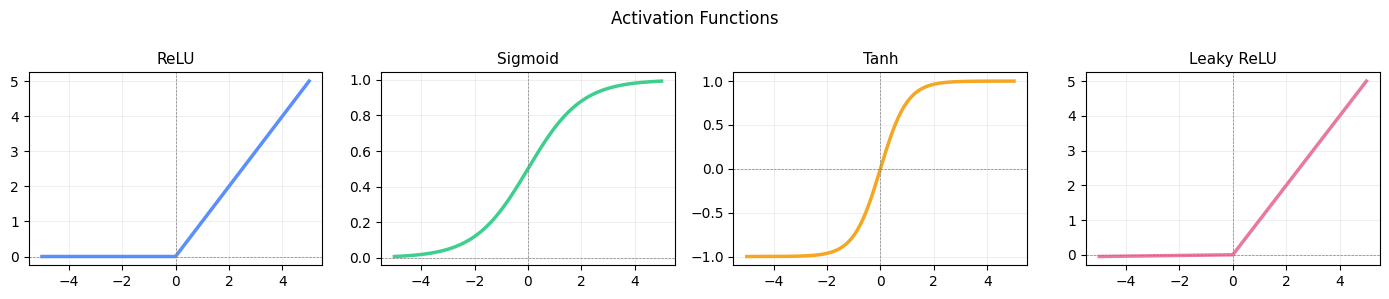

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
x=np.linspace(-5,5,300)

relu = lambda x: np.maximum(0,x)
sigmoid=lambda x:1 /(1+np.exp(-x))
tanh_fn=np.tanh
leaky = lambda x: np.where(x > 0, x, 0.01 * x)
fig,axes=plt.subplots(1,4,figsize=(14,3))
fns = [relu, sigmoid, tanh_fn, leaky]
names = ['ReLU', 'Sigmoid', 'Tanh', 'Leaky ReLU']
cols = ['#5B8FF9', '#3ECF8E', '#F5A623', '#E879A0']

for ax, fn, name, col in zip(axes, fns, names, cols):
    ax.plot(x, fn(x), color=col, linewidth=2.5)
    ax.axhline(0, color='gray', lw=0.5, ls='--')
    ax.axvline(0, color='gray', lw=0.5, ls='--')
    ax.set_title(name, fontsize=11)
    ax.grid(alpha=0.2)

plt.suptitle('Activation Functions', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
x_train=x_train.reshape(-1,784)
x_test=x_test.reshape(-1,784)

x_train=x_train.astype("float32") / 255.0
x_test=x_test.astype("float32") / 255.0
print(f'train:{x_train.shape} test: {x_test.shape}')

model=keras.Sequential(
[keras.Input(shape=(784,)),
layers.Dense(128,activation='relu'),
layers.Dropout(0.2),
layers.Dense(64,activation='relu'),
layers.Dropout(0.2),
])
model.summary()

train:(60000, 784) test: (10000, 784)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_14 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 108,736 (424.75 KB)

 Trainable params: 108,736 (424.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
early_stopping=EarlyStopping(monitor='val_loss',patience=5,restore_best_weights=True,verbose=1)
reduce_lr=ReduceLROnPlateau(monitor='val_loss',factor=0.5,patience=3,min_lr=1e-6,verbose=1)

In [ ]:
history=model.fit(x_train,y_train,epochs=50,batch_size=128,validation_split=0.1,
                  callbacks=[early_stopping,reduce_lr],verbose=1)

Epoch 1/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.1816 - loss: 4.2750 - val_accuracy: 0.1185 - val_loss: 4.0729 - learning_rate: 0.0010
Epoch 2/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.1154 - loss: 4.0927 - val_accuracy: 0.1082 - val_loss: 4.1159 - learning_rate: 0.0010
Epoch 3/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.0999 - loss: 4.1606 - val_accuracy: 0.0978 - val_loss: 4.1589 - learning_rate: 0.0010
Epoch 4/50
418/422 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0984 - loss: 4.1591
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.0993 - loss: 4.1585 - val_accuracy: 0.0978 - val_loss: 4.1589 - learning_rate: 0.0010
Epoch 5/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.0991 - loss: 4.1589 - val_accuracy: 0.0978 - val_loss: 4.1589 - learning_rate: 5.0000e-04
Epoch 6/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.0991 - loss: 4.1577

Test Accuracy: 11.68%
Test Loss: 4.0807


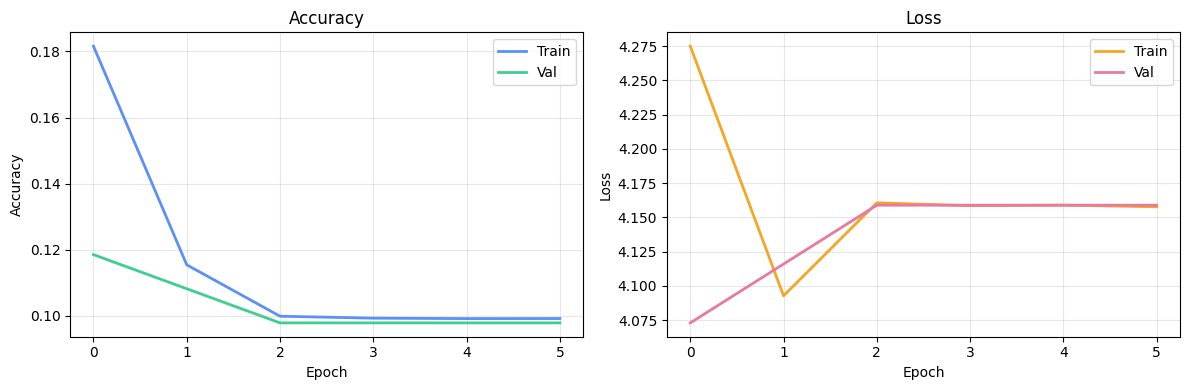

In [ ]:
# ■■ Step 7: Evaluate on test set ■■■■■■■■■■■■■■■■■■■■■■■■■■■■
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f'Test Accuracy: {test_acc*100:.2f}%') # expect 97-98%
print(f'Test Loss: {test_loss:.4f}')

# ■■ Step 8: Plot training curves ■■■■■■■■■■■■■■■■■■■■■■■■■■■■■
import matplotlib.pyplot as plt
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy
ax1.plot(history.history['accuracy'], label='Train', color='#5B8FF9', lw=2)
ax1.plot(history.history['val_accuracy'], label='Val', color='#3ECF8E', lw=2)
ax1.set(title='Accuracy', xlabel='Epoch', ylabel='Accuracy')
ax1.legend(); ax1.grid(alpha=0.3)

# Loss
ax2.plot(history.history['loss'], label='Train', color='#F5A623', lw=2)
ax2.plot(history.history['val_loss'], label='Val', color='#E879A0', lw=2)
ax2.set(title='Loss', xlabel='Epoch', ylabel='Loss')
ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()
# Reading curves:
# GOOD: both curves decline and stay close together
# OVERFIT: train keeps dropping, val starts rising
# UNDERFIT: both stay high — model too simple or not trained enough

Epoch 1/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.8747 - loss: 0.4154 - val_accuracy: 0.9613 - val_loss: 0.1331
Epoch 2/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9467 - loss: 0.1756 - val_accuracy: 0.9730 - val_loss: 0.0915
Epoch 3/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9616 - loss: 0.1276 - val_accuracy: 0.9772 - val_loss: 0.0759
Epoch 4/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9678 - loss: 0.1063 - val_accuracy: 0.9793 - val_loss: 0.0685
Epoch 5/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9712 - loss: 0.0906 - val_accuracy: 0.9798 - val_loss: 0.0674
Epoch 6/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9761 - loss: 0.0784 - val_accuracy: 0.9807 - val_loss: 0.0665
Epoch 7/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9781 - loss: 0.0700 - val_accuracy: 0.9815 - val_loss: 0.0602
Epoch 8/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9799 - loss: 0.0635 - val_accuracy:

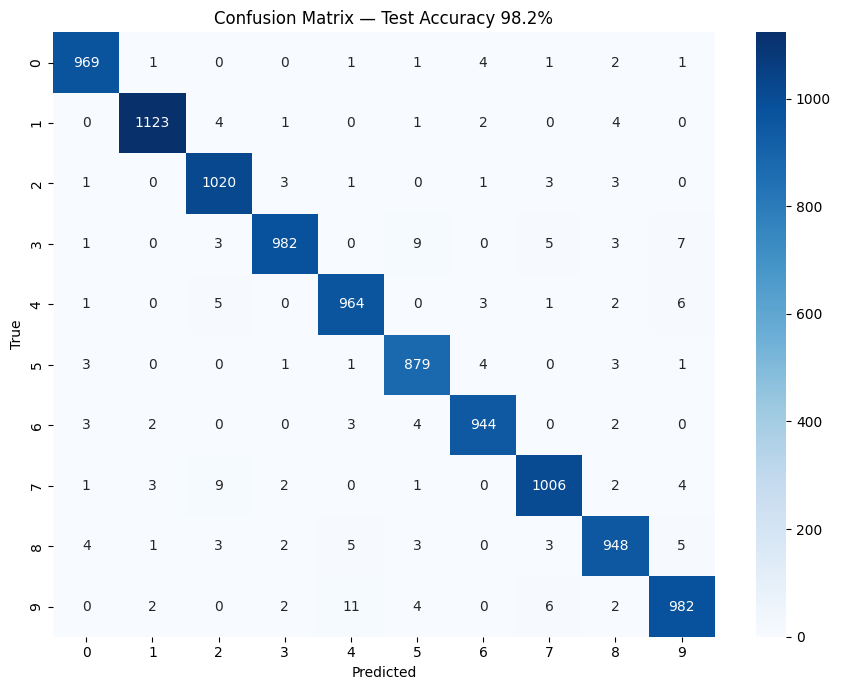

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.99      0.98      1032
           3       0.99      0.97      0.98      1010
           4       0.98      0.98      0.98       982
           5       0.97      0.99      0.98       892
           6       0.99      0.99      0.99       958
           7       0.98      0.98      0.98      1028
           8       0.98      0.97      0.97       974
           9       0.98      0.97      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000

Misclassified: 183 out of 10000


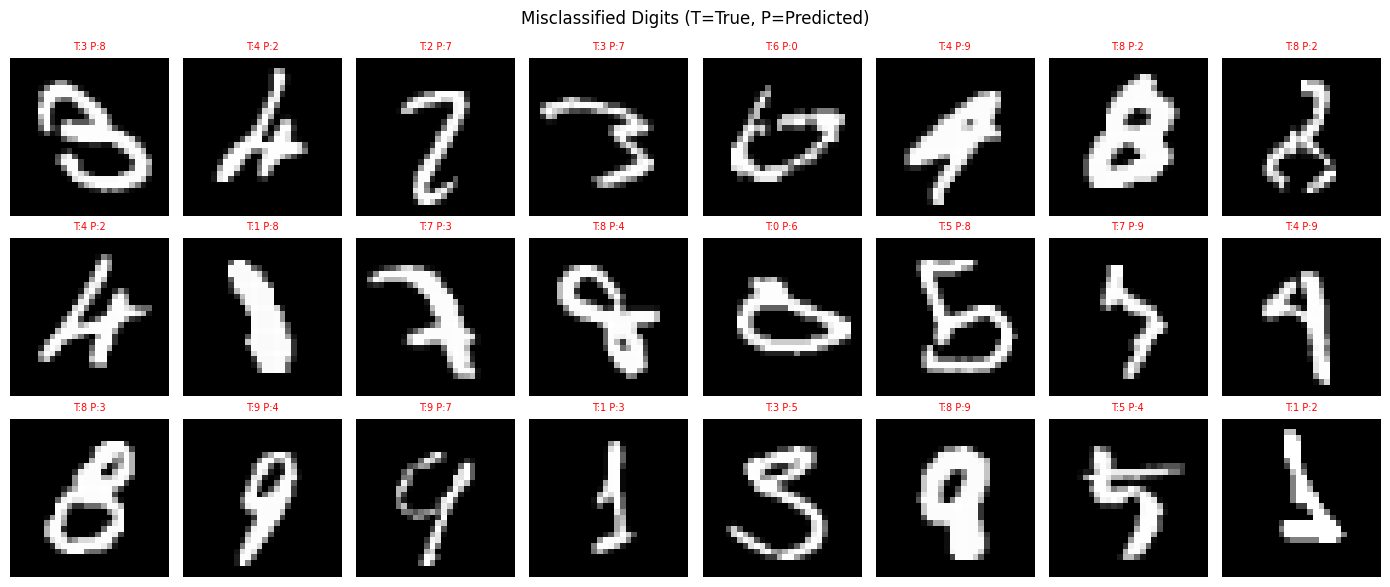

Large / moderate dropout            Accuracy: 97.82%


In [ ]:
# ■■ Train ■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■
history = model.fit(
X_train, y_train, epochs=30, batch_size=128,
validation_split=0.1,
callbacks=[EarlyStopping(patience=5, restore_best_weights=True)],
verbose=1)
# ■■ Evaluate ■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f'Test Accuracy: {acc*100:.2f}%')
# ■■ Confusion matrix ■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■
y_pred = np.argmax(model.predict(X_test), axis=1)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(9,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
xticklabels=range(10), yticklabels=range(10))
plt.title(f'Confusion Matrix — Test Accuracy {acc*100:.1f}%')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.tight_layout(); plt.show()
# Diagonal = correctly classified. Off-diagonal = confused pairs.
# Common confusions: 4 vs 9, 3 vs 8, 5 vs 6
print(classification_report(y_test, y_pred))
# ■■ Show misclassified images ■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■
wrong = np.where(y_pred != y_test)[0]
print(f'Misclassified: {len(wrong)} out of {len(y_test)}')
fig, axes = plt.subplots(3, 8, figsize=(14, 6))
for i, ax in enumerate(axes.flat):
  if i < len(wrong):
    idx = wrong[i]
    ax.imshow(X_test[idx].reshape(28,28), cmap='gray')
    ax.set_title(f'T:{y_test[idx]} P:{y_pred[idx]}',
    color='red', fontsize=7)
  ax.axis('off')
plt.suptitle('Misclassified Digits (T=True, P=Predicted)')
plt.tight_layout(); plt.show()
# ■■ Architecture comparison ■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■
configs = [
(64, 32, 0.0, 'Small / no dropout'),
(128, 64, 0.2, 'Medium / light dropout'),
(256, 128, 0.3, 'Large / moderate dropout'),
]
for h1, h2, dr, label in configs:
  m = make_model(h1, h2, dr)
  m.fit(X_train, y_train, epochs=15, batch_size=128,
    validation_split=0.1, verbose=0,
    callbacks=[EarlyStopping(patience=3, restore_best_weights=True)])
_, a = m.evaluate(X_test, y_test, verbose=0)
print(f'{label:35s} Accuracy: {a*100:.2f}%')

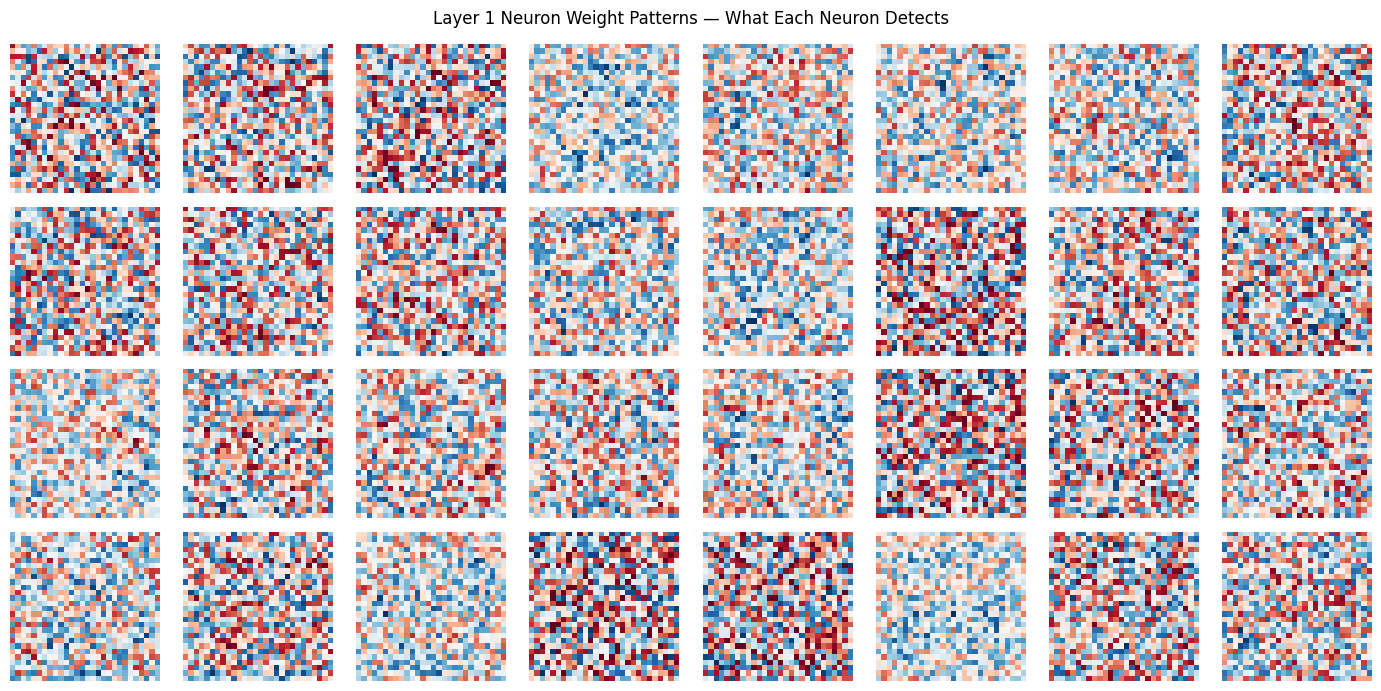

In [ ]:
# ■■ Each Layer 1 neuron has 784 weights (one per pixel) ■■■■■■■■
# Reshape to 28x28 to see which pixel patterns each neuron responds to
weights = model.layers[0].get_weights()[0] # shape: (784, 256)
fig, axes = plt.subplots(4, 8, figsize=(14, 7))
for i, ax in enumerate(axes.flat):
  w = weights[:, i].reshape(28, 28)
  ax.imshow(w, cmap='RdBu', vmin=-w.max(), vmax=w.max())
  ax.axis('off')
plt.suptitle('Layer 1 Neuron Weight Patterns — What Each Neuron Detects')
plt.tight_layout(); plt.show()
# Blue = neuron activated strongly by bright pixel here
# Red = neuron suppressed by bright pixel here